In [2]:
# Importation des bibliothèques nécessaires pour le modèle LSTM (TP consommation électrique)


# Désactivation des warnings pour un affichage plus propre
import os
import warnings

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings("ignore")

# Bibliothèques pour la manipulation et le traitement des données
import pandas as pd
import numpy as np

# Bibliothèques pour la visualisation
import matplotlib.pyplot as plt

# Prétraitement des données (normalisation)
from sklearn.preprocessing import MinMaxScaler

# Métriques d'évaluation des modèles de régression
from sklearn.metrics import (
    mean_absolute_error,          # erreur absolue moyenne
    mean_squared_error,           # erreur quadratique moyenne
    r2_score,                     # coefficient de détermination
    mean_absolute_percentage_error # erreur en pourcentage
)

import os
import warnings

# Supprime les logs TensorFlow (warnings internes)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Supprime les warnings Python classiques
warnings.filterwarnings("ignore")
# Framework deep learning TensorFlow / Keras
import tensorflow as tf



# Construction du modèle séquentiel
from tensorflow.keras.models import Sequential

# Couches du réseau de neurones (LSTM pour séries temporelles)
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Callback pour arrêter l'entraînement si amélioration stagnante
from tensorflow.keras.callbacks import EarlyStopping

# Confirmation de l'importation des bibliothèques
print("Bibliothèques importées avec succès")

Bibliothèques importées avec succès


In [3]:
# Chargement du dataset de consommation électrique (Household Power Consumption)

# Lecture du fichier texte avec séparation par ';'
# Les colonnes Date et Time sont combinées en une seule colonne datetime
# Les valeurs "?" sont considérées comme des valeurs manquantes (NaN)
data = pd.read_csv(
    "household_power_consumption.txt",
    sep=";",
    parse_dates={"datetime": ["Date", "Time"]},
    na_values=["?"],
    low_memory=False
)

# Suppression des lignes contenant des valeurs manquantes (Nettoyage du dataset)
data.dropna(inplace=True)

# Réinitialisation des index après suppression des lignes
data.reset_index(drop=True, inplace=True)

# Affichage de la taille finale du dataset
print(f" Dataset chargé : {len(data):,} lignes")

# Affichage des premières lignes pour vérifier la structure des données
data.head()

 Dataset chargé : 2,049,280 lignes


,datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
# FEATURES TEMPORELLES AVANCÉES (feature engineering pour séries temporelles)

# Extraction de l'heure à partir de la colonne datetime
data["hour"] = data["datetime"].dt.hour

# Extraction du jour de la semaine (0 = lundi, 6 = dimanche)
data["dayofweek"] = data["datetime"].dt.dayofweek

# Extraction du mois de l'année
data["month"] = data["datetime"].dt.month

# Création d'une variable binaire indiquant si c'est un week-end (samedi/dimanche)
data["is_weekend"] = (data["dayofweek"] >= 5).astype(int)

# Encodage cyclique de l'heure pour représenter la périodicité journalière
# (permet au modèle de comprendre que 23h et 0h sont proches)
data["hour_sin"] = np.sin(2 * np.pi * data["hour"] / 24)
data["hour_cos"] = np.cos(2 * np.pi * data["hour"] / 24)

# Encodage cyclique du jour de la semaine pour capturer la périodicité hebdomadaire
data["dow_sin"] = np.sin(2 * np.pi * data["dayofweek"] / 7)
data["dow_cos"] = np.cos(2 * np.pi * data["dayofweek"] / 7)

In [5]:
# Sélection des variables (features) utilisées pour la prédiction de la consommation électrique

features = [
    "Global_active_power",      # puissance active globale consommée
    "Global_reactive_power",    # puissance réactive globale
    "Voltage",                  # tension électrique
    "Global_intensity",        # intensité globale
    "Sub_metering_1",         # consommation sous-compteur 1
    "Sub_metering_2",         # consommation sous-compteur 2
    "Sub_metering_3",         # consommation sous-compteur 3
    "hour_sin",              # encodage cyclique de l'heure (sinus)
    "hour_cos",             # encodage cyclique de l'heure (cosinus)
    "is_weekend"           # indicateur week-end (0 ou 1)
]

# Conversion du DataFrame en matrice numpy pour l'entraînement du modèle
dataset = data[features].values

# Affichage du nombre de features utilisées
print(f" Nombre de features : {dataset.shape[1]}")

 Nombre de features : 10


In [6]:
# Initialisation du scaler MinMax pour la normalisation des données

# MinMaxScaler permet de ramener toutes les variables dans l'intervalle [0, 1]
scaler = MinMaxScaler()

# Ajustement du scaler sur les données puis transformation (normalisation)
dataset_scaled = scaler.fit_transform(dataset)

# Message de confirmation indiquant que la normalisation est terminée
print(" Données normalisées")

 Données normalisées


In [7]:
# Définition de la longueur de séquence utilisée pour le LSTM
# Ici, chaque échantillon utilise les 60 pas de temps précédents
SEQ_LENGTH = 60

# Fonction de création des séquences pour un modèle LSTM
def create_sequences(data, seq_length):
    
    # Liste des entrées (X) et des sorties (y)
    X = []
    y = []
    
    # Parcours du dataset pour créer des fenêtres glissantes
    for i in range(len(data) - seq_length):
        
        # Séquence d'entrée de taille seq_length
        X.append(data[i:i + seq_length])
        
        # Valeur cible : prédire la première variable (Global_active_power)
        y.append(data[i + seq_length, 0])
    
    # Conversion en tableaux numpy pour TensorFlow
    return np.array(X), np.array(y)

# Création des ensembles X (inputs) et y (target)
X, y = create_sequences(dataset_scaled, SEQ_LENGTH)

# Affichage des dimensions des données préparées
# print("X shape:", X.shape)
print("y shape:", y.shape)

y shape: (2049220,)


In [8]:
# Découpage du dataset en ensembles d'entraînement, validation et test

# 80% des données sont utilisées pour l'entraînement + validation
split = int(len(X) * 0.8)

# Séparation initiale entre train+val et test
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Création d'un ensemble de validation à partir des données d'entraînement
# 90% pour train, 10% pour validation
val_split = int(len(X_train) * 0.9)

# Extraction des données de validation
X_val = X_train[val_split:]
y_val = y_train[val_split:]

# Mise à jour des données d'entraînement (sans la validation)
X_train = X_train[:val_split]
y_train = y_train[:val_split]

In [9]:
# Définition de l'indice de séparation pour extraire la validation
val_split = int(len(X_train) * 0.9)

# Création de l'ensemble de validation à partir des données d'entraînement
X_val = X_train[val_split:]
y_val = y_train[val_split:]

# Mise à jour de l'ensemble d'entraînement (suppression des données de validation)
X_train = X_train[:val_split]
y_train = y_train[:val_split]

# Affichage de la taille de l'ensemble de validation
print(f" Validation size : {len(X_val)}")

 Validation size : 147544


In [10]:
# Définition du modèle LSTM pour la prédiction de séries temporelles

model = Sequential([

    # Couche d'entrée explicite (évite les warnings Keras)
    tf.keras.Input(shape=(X.shape[1], X.shape[2])),

    # Première couche LSTM avec 128 neurones
    LSTM(
        128,
        return_sequences=True
    ),

    # Dropout pour réduire le surapprentissage
    Dropout(0.2),

    # Deuxième couche LSTM avec 64 neurones
    LSTM(
        64,
        return_sequences=True
    ),

    # Dropout pour régularisation
    Dropout(0.2),

    # Troisième couche LSTM avec 32 neurones
    LSTM(32),

    # Dropout final
    Dropout(0.2),

    # Couche de sortie (régression)
    Dense(1)
])

# Compilation du modèle
model.compile(
    optimizer="adam",
    loss="mse"
)

# Confirmation
print("Modèle créé")

# Résumé
model.summary()



Modèle créé
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60, 128)           71168     
                                                                 
 dropout (Dropout)           (None, 60, 128)           0         
                                                                 
 lstm_1 (LSTM)               (None, 60, 64)            49408     
                                                                 
 dropout_1 (Dropout)         (None, 60, 64)            0         
                                                                 
 lstm_2 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 dense (Dense)               (None, 1)    

In [11]:
# CALLBACKS (Early Stopping pour éviter le surapprentissage)

import warnings
warnings.filterwarnings("ignore")
# EarlyStopping arrête automatiquement l'entraînement si la performance
# sur la validation ne s'améliore pas pendant un certain nombre d'époques
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",        # métrique surveillée (loss de validation)
    patience=3,                # nombre d'époques sans amélioration avant arrêt
    restore_best_weights=True  # restaure les meilleurs poids obtenus
)

# Entraînement du modèle LSTM
history = model.fit(

    # Sous-échantillonnage des données d'entraînement pour accélérer l'apprentissage
    X_train[:80000],
    y_train[:80000],

    # Données de validation utilisées pour surveiller la performance
    validation_data=(X_val[:5000], y_val[:5000]),

    # Nombre maximum d'époques d'entraînement
    epochs=15,

    # Taille des batches (nombre d'échantillons par mise à jour)
    batch_size=64,

    # Callback pour arrêt anticipé si stagnation
    callbacks=[early_stop],

    # Affichage détaillé de l'entraînement
    verbose=1
)

# Message de fin d'entraînement
print("Entraînement terminé")

Epoch 1/15

1250/1250 [==============================] - 92s 69ms/step - loss: 0.0030 - val_loss: 7.2956e-04
Epoch 2/15
1250/1250 [==============================] - 89s 71ms/step - loss: 0.0017 - val_loss: 4.4206e-04
Epoch 3/15
1250/1250 [==============================] - 93s 75ms/step - loss: 0.0014 - val_loss: 4.2134e-04
Epoch 4/15
1250/1250 [==============================] - 98s 78ms/step - loss: 0.0014 - val_loss: 4.5068e-04
Epoch 5/15
1250/1250 [==============================] - 105s 84ms/step - loss: 0.0013 - val_loss: 4.1711e-04
Epoch 6/15
1250/1250 [==============================] - 106s 85ms/step - loss: 0.0013 - val_loss: 4.0461e-04
Epoch 7/15
1250/1250 [==============================] - 108s 86ms/step - loss: 0.0013 - val_loss: 4.2539e-04
Epoch 8/15
1250/1250 [==============================] - 107s 85ms/step - loss: 0.0012 - val_loss: 4.0079e-04
Epoch 9/15
1250/1250 [==============================] - 106s 85ms/step - loss: 0.0012 - val_loss: 4.1626e-04
Epoch 10/15
1250/1250 

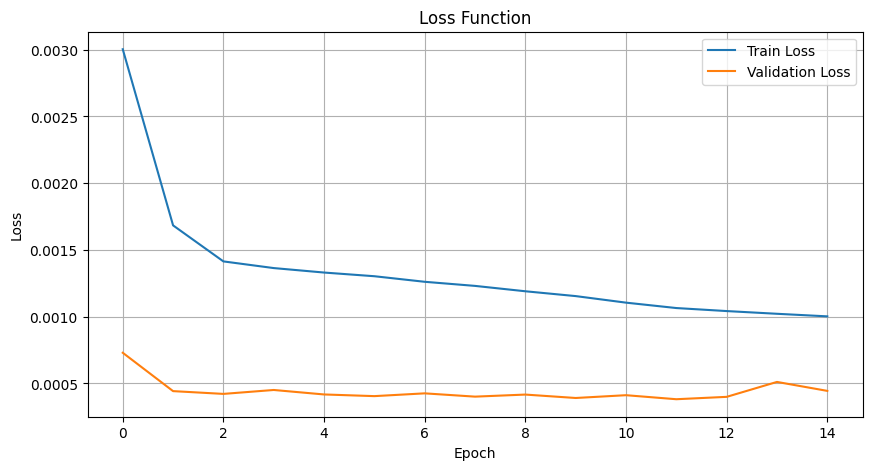

In [12]:
# Création de la figure avec une taille de 10x5 pouces
plt.figure(figsize=(10,5))

# Tracé de la courbe de la loss sur l'ensemble d'entraînement
plt.plot(history.history["loss"], label="Train Loss")

# Tracé de la courbe de la loss sur l'ensemble de validation
plt.plot(history.history["val_loss"], label="Validation Loss")

# Titre principal du graphique
plt.title("Loss Function")

# Label de l’axe des abscisses (epochs)
plt.xlabel("Epoch")

# Label de l’axe des ordonnées (valeur de la loss)
plt.ylabel("Loss")

# Affichage de la légende (Train vs Validation)
plt.legend()

# Activation de la grille pour faciliter la lecture
plt.grid()

# Affichage final du graphique
plt.show()

In [13]:
# Génération des prédictions du modèle sur le jeu de test
y_pred = model.predict(X_test)

# Reshape des vraies valeurs pour avoir une forme compatible (colonne unique)
y_test = y_test.reshape(-1, 1)

# Message de confirmation indiquant que les prédictions sont terminées
print("Prédictions effectuées")


12808/12808 [==============================] - 250s 19ms/step
Prédictions effectuées


In [17]:
# Reconstruction des valeurs réelles de y_test (annulation de la normalisation)

# On réinjecte y_test dans une matrice complète car le scaler a été entraîné sur toutes les features
# Les autres colonnes sont remplies par des zéros (non utilisées pour l'inversion de y uniquement)
y_test_real = scaler.inverse_transform(
    np.concatenate(
        [y_test, np.zeros((len(y_test), len(features) - 1))],
        axis=1
    )
)[:, 0]

# Reconstruction des valeurs prédites en échelle réelle
y_pred_real = scaler.inverse_transform(
    np.concatenate(
        [y_pred, np.zeros((len(y_pred), len(features) - 1))],
        axis=1
    )
)[:, 0]

In [18]:
# Calcul de l'erreur absolue moyenne (MAE)
mae = mean_absolute_error(y_test_real, y_pred_real)

# Calcul de la racine de l'erreur quadratique moyenne (RMSE)
rmse = np.sqrt(
    mean_squared_error(y_test_real, y_pred_real)
)

# Calcul de l'erreur moyenne absolue en pourcentage (MAPE)
mape = mean_absolute_percentage_error(
    y_test_real,
    y_pred_real
)

# Calcul du coefficient de détermination (R²)
r2 = r2_score(
    y_test_real,
    y_pred_real
)

# Import des métriques (si non déjà importées)
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# Affichage des résultats finaux d'évaluation
print("========== METRICS FINALES ==========")

# Affichage de la MAE
print("MAE  :", mae)

# Affichage du RMSE
print("RMSE :", rmse)

# Affichage du MAPE
print("MAPE :", mape)

# Affichage du R2 score
print("R2   :", r2)

========== METRICS FINALES ==========
MAE  : 0.09388253564627681
RMSE : 0.21396643083720407
MAPE : 0.12495009422754487
R2   : 0.9429766468885696


In [19]:
# Baseline simple (modèle naïf) : on prédit la valeur précédente

# Décalage des valeurs réelles de y_test d'un pas pour créer une baseline
baseline = np.roll(y_test_real, 1)

# Correction de la première valeur (car elle est invalide après le décalage)
baseline[0] = baseline[1]

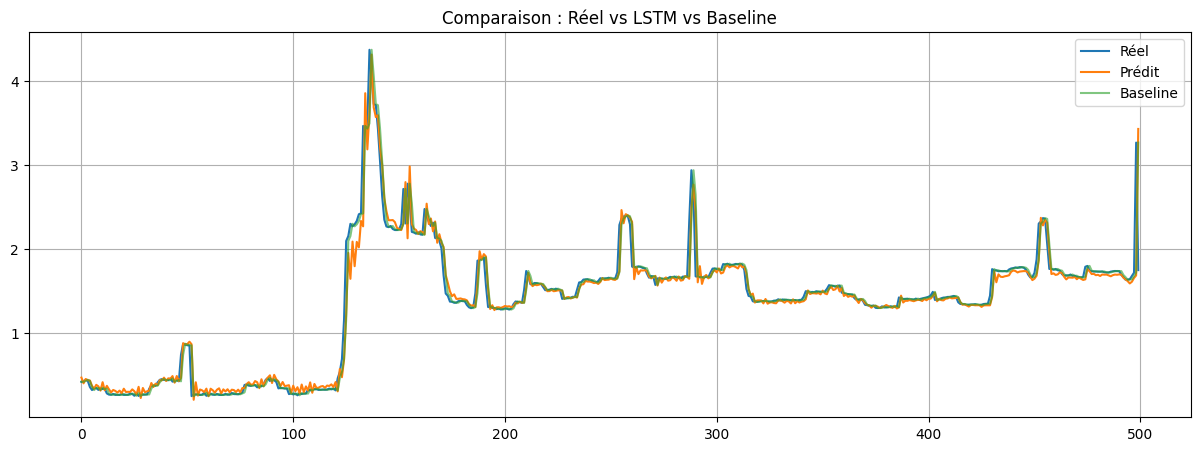

In [20]:
# Création de la figure pour comparer les résultats
plt.figure(figsize=(15,5))

# Affichage des valeurs réelles sur les 500 premiers points
plt.plot(y_test_real[:500], label="Réel")

# Affichage des prédictions du modèle LSTM sur les 500 premiers points
plt.plot(y_pred_real[:500], label="Prédit")

# Affichage de la baseline (modèle naïf : valeur précédente)
plt.plot(baseline[:500], label="Baseline", alpha=0.6)

# Titre du graphique comparatif
plt.title("Comparaison : Réel vs LSTM vs Baseline")

# Affichage de la légende
plt.legend()

# Ajout de la grille pour améliorer la lecture
plt.grid()

# Affichage final du graphique
plt.show()

In [21]:
# BASELINE SIMPLE (très important pour l'évaluation du modèle)

# Création d'une baseline naïve : prédiction = valeur précédente
baseline = np.roll(y_test_real, 1)

# Calcul de l'erreur MAE pour la baseline
baseline_mae = mean_absolute_error(y_test_real, baseline)

# Affichage des résultats de comparaison
print("========== BASELINE ==========")

# Affichage de la MAE de la baseline
print(f"Baseline MAE : {baseline_mae:.4f}")

# Affichage de la MAE du modèle LSTM
print(f"Model MAE    : {mae:.4f}")

# Comparaison entre modèle et baseline
if mae < baseline_mae:
    print("Modèle meilleur que baseline")
else:
    print("Baseline meilleur (problème modèle)")

========== BASELINE ==========
Baseline MAE : 0.0719
Model MAE    : 0.0939
Baseline meilleur (problème modèle)


In [22]:
# Sauvegarde du modèle LSTM entraîné au format H5

# Enregistrement du modèle complet (architecture + poids + optimizer si nécessaire)
model.save("stacked_lstm_model.h5")

# Message de confirmation de la sauvegarde
print("Modèle sauvegardé")

Modèle sauvegardé
